In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import r2_score
import os 
import glob
import math


In [278]:
class Test:
    def __init__(self, df):
        self.df = df.copy()  # Avoid modifying the original DataFrame
        self.id = df['participant_ID'].iloc[0]
        self.date = df['visit_date'].iloc[0]
        self.name = f"{self.id}_{self.date}"
        
        # Assign 'Stage' only for 'EXERCISE' phase, then fill NaN values with 0
        self.df['Stage'] = np.nan
        exercise_mask = self.df['Phase'] == 'EXERCISE'
        self.df.loc[exercise_mask, 'Stage'] = self.df[exercise_mask].groupby(['Speed', 'Grade']).ngroup() + 1
        self.df['Stage']= self.df['Stage'].fillna(0)  # Ensure non-exercise rows have Stage 0
        
        # Convert 't' to timedelta and set it as index
        self.df['t'] = pd.to_timedelta(self.df['t'])
        self.df.set_index('t', inplace=True)
        
        self.lactate_df = self.prepare_lactate_df()
    
    def prepare_lactate_df(self):
        # Reset index to retrieve 't' column
        lactate_df = self.df.dropna(subset=['La-']).reset_index()
        lactate_df = lactate_df[['t', 'La-', 'Phase', 'Speed', 'Grade', 'Stage']]
        
        # Remove extreme lactate values (greater than 20)
        lactate_df = lactate_df[lactate_df['La-'] <= 20]
        
        # Apply logarithmic transformation, handling non-positive values
        lactate_df['log_lactate'] = np.log(lactate_df['La-'].replace(0, np.nan))
        lactate_df['log_speed'] = np.log(lactate_df['Speed'].replace(0, np.nan))
        
        return lactate_df


    def lactate_graph(self):
        # Separate logic for graphing
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        self.plot_lactate_reference(axes[0])
        self.plot_lactate_absolute(axes[1])
        plt.tight_layout()
        return plt

    def plot_lactate_reference(self, ax):
        ax.plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        ax.set_xlabel('Time')
        ax.set_ylabel('Lactate mmol/L')
        ax.set_title('Lactate vs Time Using Reference ' + self.name)
        ax.set_ylim(0, None)

        LT1_ref, LT2_ref, _, _ = self.lt_ref_vals()
        if LT1_ref:
            ax.axvline(x=LT1_ref, color='r', label='LT1')
        if LT2_ref:
            ax.axvline(x=LT2_ref, color='g', linestyle='--', label='LT2')

        ax.set_xticks(self.lactate_df['t'])
        ax.legend(loc='upper left')

    def plot_lactate_absolute(self, ax):
        ax.plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        ax.set_xlabel('Time')
        ax.set_ylabel('Lactate mmol/L')
        ax.set_title('Lactate vs Time Using Absolute ' + self.name)
        ax.set_ylim(0, None)

        LT1_abs, LT2_abs, _, _ = self.lt_abs_vals()
        ax.axhline(y=2, color='r', label='Threshold 2 mmol/L')
        ax.axhline(y=4, color='g', linestyle='--', label='Threshold 4 mmol/L')

        ax.set_xticks(self.lactate_df['t'])
        ax.legend(loc='upper left')

    def lt_ref_vals(self):
        lt1ref_index = (self.lactate_df['La-'].diff() >= 0.5)
        lt2ref_index = (self.lactate_df['La-'].diff() >= 1)
        LT1ref = self.lactate_df.loc[lt1ref_index.idxmax(), 'La-'] if lt1ref_index.any() else None
        LT2ref = self.lactate_df.loc[lt2ref_index.idxmax(), 'La-'] if lt2ref_index.any() else None
        LT1ref_speed = self.lactate_df.loc[lt1ref_index.idxmax(), 'Speed'] if lt1ref_index.any() else None
        LT2ref_speed = self.lactate_df.loc[lt2ref_index.idxmax(), 'Speed'] if lt2ref_index.any() else None
        results = {"LT1_ref":LT1ref, "LT2_ref":LT2ref, "LT1ref_speed":LT1ref_speed, "LT2ref_speed":LT2ref_speed}
        return results

    def lt_abs_vals(self):
        lt1abs_index = (self.lactate_df['La-'] >= 2)
        lt2abs_index = (self.lactate_df['La-'] >= 4)
        
        LT1abs = self.lactate_df.loc[lt1abs_index.idxmax(), 'La-'] if lt1abs_index.any() else None
        LT2abs = self.lactate_df.loc[lt2abs_index.idxmax(), 'La-'] if lt2abs_index.any() else None
        LT1abs_speed = self.lactate_df.loc[lt1abs_index.idxmax(), 'Speed'] if lt1abs_index.any() else None
        LT2abs_speed = self.lactate_df.loc[lt2abs_index.idxmax(), 'Speed'] if lt2abs_index.any() else None
        
        results = {
            "LT1_abs": LT1abs, 
            "LT2_abs": LT2abs, 
            "LT1abs_speed": LT1abs_speed, 
            "LT2abs_speed": LT2abs_speed
        }
        return results

    def heart_rate_graph(self):
        fig, ax1 = plt.subplots(figsize=(10, 5))
        exercise_df = self.df[self.df['Phase'] == 'EXERCISE']
        rolling_mean = exercise_df['VO2'].rolling(window=5).mean()

        ax1.plot(exercise_df['t'], rolling_mean, color='blue', label='Heart Rate')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Heart Rate')
        ax1.set_title('Heart Rate and Speed Over Time')
        ax1.grid(True)

        stage_changes = exercise_df[exercise_df['Stage'] != exercise_df['Stage'].shift()]
        stage_times = stage_changes['t']

        for time in stage_times:
            ax1.axvline(x=time, color='red', linestyle='--', alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(exercise_df['t'], exercise_df['Speed'], color='black', linestyle='-', alpha=0.6, label='Speed')
        ax2.set_ylabel('Speed (mph)', color='black')
        ax2.tick_params(axis='y', labelcolor='black')

        lactate_times = self.lactate_df['t'][:-3]
        ax1.set_xticks(lactate_times)

        fig.tight_layout()
        plt.show()

    
    def linear_regression(self, x, y):
        """Perform linear regression and return slope, intercept, and r-value."""
        slope, intercept, r_value, _, _ = linregress(x, y)
        return slope, intercept, r_value
    def find_best_split(self, x, y):
        """Finds the best split point for two linear regression fits with one overlapping point and computes the best R²"""
        best_r2_combined = -np.inf
        best_params = None
        
        if len(x) == 4:
            split_points = [2]  # Only one valid split at index 2
        else:
            split_points = range(2, len(x) - 1)  # Ensure one overlapping point
        
        for split in split_points:  
            x_first, y_first = x[:split + 1], y[:split + 1]  # Include split point in first segment
            x_last, y_last = x[split:], y[split:]  # Include split point in second segment

            # Perform linear regression
            slope_first, intercept_first = np.polyfit(x_first, y_first, 1)
            slope_last, intercept_last = np.polyfit(x_last, y_last, 1)

            # Compute intersection point
            x_intersect, y_intersect = self.compute_intersection(slope_first, intercept_first, slope_last, intercept_last)

            # Predict values for R² calculation
            y_pred_first = slope_first * x_first + intercept_first
            y_pred_last = slope_last * x_last + intercept_last

            # Calculate R² values
            r2_first = r2_score(y_first, y_pred_first)
            r2_last = r2_score(y_last, y_pred_last)

            # Compute weighted R²
            r2_combined = ((len(x_first) * r2_first) + (len(x_last) * r2_last)) / (len(x_first) + len(x_last))

            # Track best split
            if r2_combined > best_r2_combined:
                best_r2_combined = r2_combined
                best_params = (slope_first, intercept_first, slope_last, intercept_last, x_intersect, y_intersect, r2_first, r2_last)
        
        return best_params, best_r2_combined

    def compute_intersection(self, m1, b1, m2, b2):
        """Finds intersection of two lines y = m1*x + b1 and y = m2*x + b2"""
        if m1 == m2:
            return None, None  # Parallel lines, no intersection
        x_intersect = (b2 - b1) / (m1 - m2)
        y_intersect = m1 * x_intersect + b1
        return x_intersect, y_intersect

    def plot_results(self, ax, x, y, params, title, xlabel, ylabel):
        slope_first, intercept_first, slope_last, intercept_last, x_intersect, y_intersect, r2_first, r2_last = params

        ax.scatter(x, y, color='black', label='Data')

        # Define x-range for the full span of the graph
        x_min, x_max = min(x), max(x)
        x_range = np.linspace(x_min, x_max, 100)  # Generate a smooth range of x-values

        # Compute y-values for the extended regression lines
        y_first = slope_first * x_range + intercept_first
        y_last = slope_last * x_range + intercept_last

        # Plot the regression lines
        ax.plot(x_range, y_first, 'r-', label=f'Line 1 (R²={r2_first:.2f})')
        ax.plot(x_range, y_last, 'g-', label=f'Line 2 (R²={r2_last:.2f})')

        # Plot the intersection point
        ax.scatter(x_intersect, y_intersect, color='blue', zorder=3, label='Intersection')

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend()
        ax.grid(True)

        # Ensure y-axis starts at 0
        ax.set_ylim(bottom=0)

    def lactate_log_graph(self):
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        data_dict = self.lt_log_semilog_vals()
    
    def v_slope_method(self, x_list, y_list):
        """Finds the optimal intersection point using the V-Slope method."""
        split_index = len(x_list) // 2
        best_index = split_index
        min_error = float('inf')
        
        for i in range(10, len(x_list) - 10):  # Ensure enough points for both regressions
            slope1, intercept1, _, _, _ = linregress(x_list[:i], y_list[:i])
            slope2, intercept2, _, _, _ = linregress(x_list[i:], y_list[i:])
            
            if slope1 < 1 and slope2 >= 1:  # Condition for V-slope method
                error = np.sum((y_list[:i] - (slope1 * x_list[:i] + intercept1))**2) + \
                        np.sum((y_list[i:] - (slope2 * x_list[i:] + intercept2))**2)
                if error < min_error:
                    min_error = error
                    best_index = i
        
        slope1, intercept1, _, _, _ = linregress(x_list[:best_index], y_list[:best_index])
        slope2, intercept2, _, _, _ = linregress(x_list[best_index:], y_list[best_index:])
        
        x_threshold = (intercept2 - intercept1) / (slope1 - slope2)
        y_threshold = slope1 * x_threshold + intercept1
        
        return best_index, slope1, intercept1, slope2, intercept2, x_threshold, y_threshold  
            

    def lt_log_semilog(self, plot=False):
        """Creates LT1 (log-log) and LT2 (semi-log) plots with best two-segment regression fits and intersections"""
        # === Prepare Data ===
        filtered_df = self.lactate_df.drop_duplicates(subset='Speed', keep='first')
        filtered_df = filtered_df[(filtered_df['Speed'] > 0) & (filtered_df['La-'] > 0)]

        log_speed = np.log(filtered_df['Speed'])
        log_lactate = np.log(filtered_df['La-'])
        speed = filtered_df['Speed']

        # === LT1: Log Speed vs Log Lactate ===
        best_params_lt1, best_r2_combined_lt1 = self.find_best_split(log_speed, log_lactate)
        if best_params_lt1:
            x_intersect_lt1, y_intersect_lt1 = best_params_lt1[4:6]
            lt1_log = math.exp(y_intersect_lt1)
            lt1_log_speed = math.exp(x_intersect_lt1)
            lt1_log_r2 = best_r2_combined_lt1
        else:
            lt1_log = None
            lt1_log_speed = None
            lt1_log_r2 = None
            
        #self.plot_results(axs[0], log_speed, log_lactate, best_params_lt1, 
         #                 'LT1: Log Speed vs Log Lactate', 'Log Speed', 'Log Lactate')

        best_params_lt2, best_r2_combined_lt2 = self.find_best_split(speed, log_lactate)
        if best_params_lt2:
            x_intersect_lt2, y_intersect_lt2 = best_params_lt2[4:6]
            lt2_semilog = x_intersect_lt2
            lt2_semilog_speed = math.exp(y_intersect_lt2)
            lt2_semi_log_r2 = best_r2_combined_lt2
        else:
            lt2_semilog = None
            lt2_semilog_speed = None
            lt2_semi_log_r2 = None

        #self.plot_results(axs[1], speed, log_lactate, best_params_lt2, 
        #                  'LT2: Speed vs Log Lactate', 'Speed', 'Log Lactate')
        if plot:
            fig, axs = plt.subplots(1, 2, figsize=(12, 5))
            if best_params_lt1:
                self.plot_results(axs[0], log_speed, log_lactate, best_params_lt1, 'LT1: Log Speed vs Log Lactate', 'Log Speed', 'Log Lactate')
            if best_params_lt2:
                self.plot_results(axs[1], speed, log_lactate, best_params_lt2, 'LT2: Speed vs Log Lactate', 'Speed', 'Log Lactate')
            plt.tight_layout()
            plt.show()
        return {
            "LT1_log":  lt1_log,
            "LT1_log_speed": lt1_log_speed,
            "LT1_log_r2": lt1_log_r2,
            "LT2_semilog": lt2_semilog, 
            "LT2_semilog_speed": lt2_semilog_speed,
            "LT2_semi_log_r2": lt2_semi_log_r2
        } 
    def aerobic_1(self):
        vo2 = self.df['VO2']
        vco2 = self.df['VCO2']
        
        # Define an initial split index to separate the two regression regions
        split_index = len(vo2) // 2
        
        # Function to find the optimal intersection point
        best_index = split_index
        min_error = float('inf')
        
        for i in range(10, len(vo2) - 10):  # Ensure enough points for both regressions
            slope1, intercept1, _, _, _ = linregress(vo2[:i], vco2[:i])
            slope2, intercept2, _, _, _ = linregress(vo2[i:], vco2[i:])
            
            if slope1 < 1 and slope2 >= 1:  # Condition for V-slope method
                error = np.sum((vco2[:i] - (slope1 * vo2[:i] + intercept1))**2) + \
                        np.sum((vco2[i:] - (slope2 * vo2[i:] + intercept2))**2)
                if error < min_error:
                    min_error = error
                    best_index = i
        
        # Compute best fit lines
        slope1, intercept1, _, _, _ = linregress(vo2[:best_index], vco2[:best_index])
        slope2, intercept2, _, _, _ = linregress(vo2[best_index:], vco2[best_index:])
        
        # Intersection point
        vo2_threshold = (intercept2 - intercept1) / (slope1 - slope2)
        vco2_threshold = slope1 * vo2_threshold + intercept1
        
        # Create plot
        fig, ax = plt.subplots(figsize=(8,6))
        ax.scatter(vo2, vco2, label='Data', color='lightgray')
        ax.plot(vo2[:best_index], slope1 * vo2[:best_index] + intercept1, 'b', label='Slope < 1')
        ax.plot(vo2[best_index:], slope2 * vo2[best_index:] + intercept2, 'r', label='Slope ≥ 1')
        ax.scatter(vo2_threshold, vco2_threshold, color='black', zorder=3, label='Intersection Point')
        
        ax.set_xlabel('VO2 (L/min)')
        ax.set_ylabel('VCO2 (L/min)')
        ax.set_title('V-Slope Method for Aerobic Threshold')
        ax.set_xlim(0, None)
        ax.set_ylim(0, None)
        ax.legend()
        ax.grid()
        
        
        
        return fig, vo2_threshold, vco2_threshold
    def aerobic_2(self, window_size, plot=False):
        VE_VO2 = self.df['VE/VO2'].rolling(f'{window_size}s', min_periods=1).mean()
        VE_CO2 = self.df['VE/VCO2'].rolling(f'{window_size}s', min_periods=1).mean()

        # Convert time index to total seconds
        time = self.df.index.total_seconds()
        # Identify nadir: Minimum VE/VO2 value
        nadir_index = VE_VO2.idxmin()
        if pd.isna(nadir_index) or nadir_index not in self.df.index:
            raise ValueError("nadir_index is NaN or not in DataFrame index")

        nadir_time = self.df.index[self.df.index.get_loc(nadir_index)]  # Safer method to get position
        nadir_value = VE_VO2[nadir_index]

        # Find the first rise after nadir while VE/CO2 is constant or increasing
        rise_index = None

        nadir_seconds = nadir_time.total_seconds()  # Convert Timedelta to seconds
        end_seconds = self.df.index[-1].total_seconds()
        for index in VE_CO2.index[1:]:
            prev_index = VE_CO2.index[VE_CO2.index < index].max()
            if VE_CO2.loc[index] >= VE_CO2.loc[prev_index] and VE_VO2.loc[index] > nadir_value:
                rise_index = prev_index
                break

        if rise_index is not None:
            rise_time = rise_index.total_seconds()
            rise_VE_VO2 = VE_VO2[rise_index]
            rise_VE_CO2 = VE_CO2[rise_index]
            #print(f"First rise after nadir found at time {rise_time} sec with VE/VO2 = {rise_VE_VO2} and VE/CO2 = {rise_VE_CO2}")
        else:
            print("No first rise after nadir found.")
        # Find the deflection point of VE/CO2 after nadir_index
        deflection_index = None
        for index in VE_CO2.index[VE_CO2.index > nadir_index]:
            if (index.total_seconds() - nadir_seconds) < 100:
                continue  # Ensure at least 5 seconds have passed
            prev_index = VE_CO2.index[VE_CO2.index < index].max()
            next_index = VE_CO2.index[VE_CO2.index > index].min()
            
            if prev_index is not None and next_index is not None:
                prev_slope = VE_CO2.loc[index] - VE_CO2.loc[prev_index]
                next_slope = VE_CO2.loc[next_index] - VE_CO2.loc[index]
                
                if prev_slope > 0 and next_slope < 0:  # Detect peak or deflection
                    deflection_index = index
                    break

        if deflection_index is not None:
            deflection_time = deflection_index.total_seconds()
            deflection_VE_CO2 = VE_CO2[deflection_index]
            #print(f"Deflection point of VE/CO2 found at time {deflection_time} sec with VE/CO2 = {deflection_VE_CO2}")
        else:
            print("No deflection point of VE/CO2 found after nadir.")
        if plot:
            fig, ax = plt.subplots(figsize=(8, 6))

            ax.plot(time, VE_VO2, color='b', label='VE/VO2', zorder=2)
            ax.plot(time, VE_CO2, color='r', label='VE/CO2', zorder=1)
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Value')
            ax.tick_params(axis='y')

            # Mark the nadir, first rise, and deflection points
            ax.scatter(nadir_seconds, nadir_value, color='black', zorder=3, label='Nadir')
            if rise_index is not None:
                ax.scatter(rise_time, rise_VE_VO2, color='green', zorder=3, label='First Rise')
            if deflection_index is not None:
                ax.scatter(deflection_time, deflection_VE_CO2, color='purple', zorder=3, label='Deflection Point')

            fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
            ax.grid(True)
            plt.title('VE/VO2 and VE/CO2 vs. Time')
            #plt.show()

        return {'vt1_time': nadir_time, 'vt1_VE_VO2': VE_VO2.loc[nadir_index], 'vt1_VE_CO2': VE_CO2.loc[nadir_index],
                'vt2_time': deflection_time if deflection_index is not None else None,
                'vt2_VE_VO2': VE_VO2.loc[deflection_index] if deflection_index is not None else None,
                'vt2_VE_CO2': deflection_VE_CO2 if deflection_index is not None else None}
    
 
    def ve_vs_wl(self):
        mean_VE_VO2 = self.df.groupby('Stage')['VE/VO2'].mean()
        mean_VE_CO2 = self.df.groupby('Stage')['VE/VCO2'].mean()

        # Plot the mean VE/VO2 and mean VE/CO2 for each stage
        fig, ax = plt.subplots(figsize=(8, 6))
        mean_VE_VO2.plot(kind='line', color='b', label='Mean VE/VO2', ax=ax)
        mean_VE_CO2.plot(kind='line', color='r', label='Mean VE/CO2', ax=ax)
        ax.set_xlabel('Stage')
        ax.set_ylabel('Value')
        ax.legend()
        plt.title('Mean VE/VO2 and Mean VE/CO2 for Each Stage')
        
    def aerobic_anaerobic_3(self, window_size, plot=False):
            # Apply rolling mean
        PetO2 = self.df['PetO2'].rolling(f'{window_size}s', min_periods=1).mean()
        PetCO2 = self.df['PetCO2'].rolling(f'{window_size}s', min_periods=1).mean()
        
        # Convert time index to total seconds
        time = self.df.index.total_seconds()
        # Identify nadir: Minimum PetO2 value
        nadir_index = PetO2.idxmin()
        if pd.isna(nadir_index) or nadir_index not in self.df.index:
            raise ValueError("nadir_index is NaN or not in DataFrame index")

        nadir_time = self.df.index[self.df.index.get_loc(nadir_index)]  # Safer method to get position
        nadir_value = PetO2[nadir_index]

        # Find the first rise after nadir while PetCO2 is constant or increasing
        rise_index = None

        nadir_seconds = nadir_time.total_seconds()  # Convert Timedelta to seconds
        end_seconds = self.df.index[-1].total_seconds()
        for index in PetCO2.index[1:]:
            prev_index = PetCO2.index[PetCO2.index < index].max()
            if PetCO2.loc[index] >= PetCO2.loc[prev_index] and PetO2.loc[index] > nadir_value:
                rise_index = prev_index
                break

        if rise_index is not None:
            rise_time = rise_index.total_seconds()
            rise_PetO2 = PetO2[rise_index]
            rise_PetCO2 = PetCO2[rise_index]
            #print(f"First rise after nadir found at time {rise_time} sec with PetO2 = {rise_PetO2} and PetCO2 = {rise_PetCO2}")
        else:
            print("No first rise after nadir found.")
        # Compute the first derivative (rate of change) --> after aerobic threshold
        mask = PetCO2.index > nadir_index
        dPetCO2_dt = np.gradient(PetCO2[mask], time[mask])

        # Compute the second derivative (change in rate)
        d2PetCO2_dt2 = np.gradient(dPetCO2_dt, time[mask])

        # Find the deflection point where the second derivative changes significantly
        deflection_index = np.argmax((d2PetCO2_dt2)) 
        #deflection_index = np.argmax(np.abs(d2PetCO2_dt2))  # Max absolute change
        deflection_time = time[deflection_index]
        deflection_value = PetCO2.iloc[deflection_index]

        # Print results
        #print(f"Deflection point found at time {deflection_time} sec with PetCO2 = {deflection_value}")
        # Plot PetO2 and PetCO2
        if plot:
            fig, ax1 = plt.subplots(figsize=(8, 6))

            ax1.plot(time, PetO2, color='b', label='PetO2', zorder=2)
            ax1.set_xlabel('Time (s)')
            ax1.set_ylabel('PetO2 (L/min)', color='b')
            ax1.tick_params(axis='y', labelcolor='b')

            ax2 = ax1.twinx()
            ax2.plot(time, PetCO2, color='r', label='PetCO2', zorder=1)
            ax2.set_ylabel('PetCO2 (L/min)', color='r')
            ax2.tick_params(axis='y', labelcolor='r')

            # Mark the nadir, first rise, and deflection points
            ax1.scatter(nadir_index.total_seconds(), nadir_value, color='black', zorder=3, label='Nadir')
            if rise_index is not None:
                ax1.scatter(rise_time, rise_PetO2, color='green', zorder=3, label='First Rise')
            ax2.scatter(deflection_time, deflection_value, color='purple', zorder=3, label='Deflection Point')

            fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
            ax1.grid(True)
            plt.title('PetO2 and PetCO2 vs. Time')
            #plt.show()

        return {'vt1_time':nadir_time, 'vt1_O2_val': PetO2.loc[nadir_index], 'vt1_CO2_val': PetCO2.loc[nadir_index], 'vt2_time': deflection_time, 'vt2_O2_val': PetO2.iloc[deflection_index], 'vt2_CO2_val':  deflection_value}

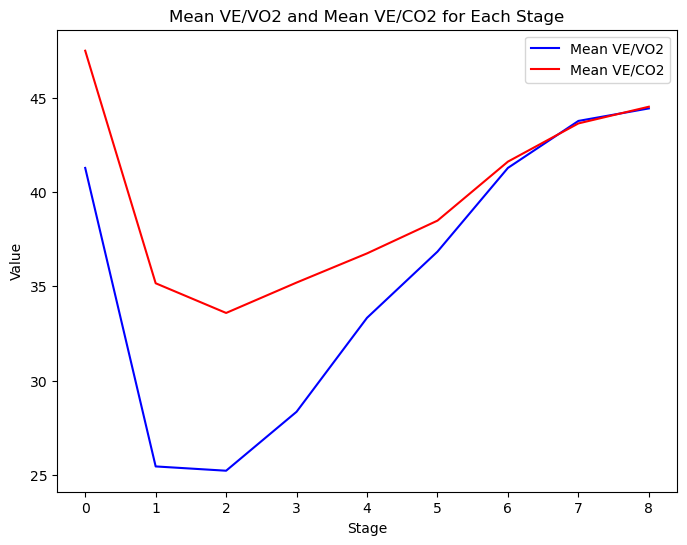

In [283]:
df = pd.read_csv('visit_data/TR000102_20220204_visit_data.csv')
test = Test(df)
test.ve_vs_wl()

/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_18537/241605824.py:427: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 6))


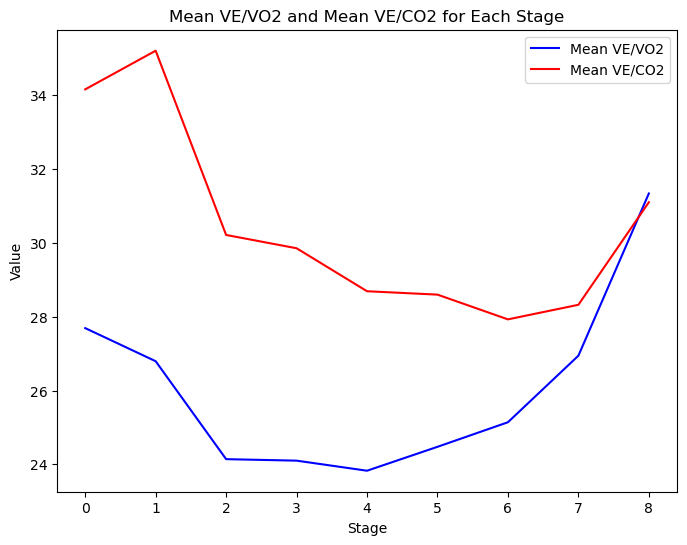

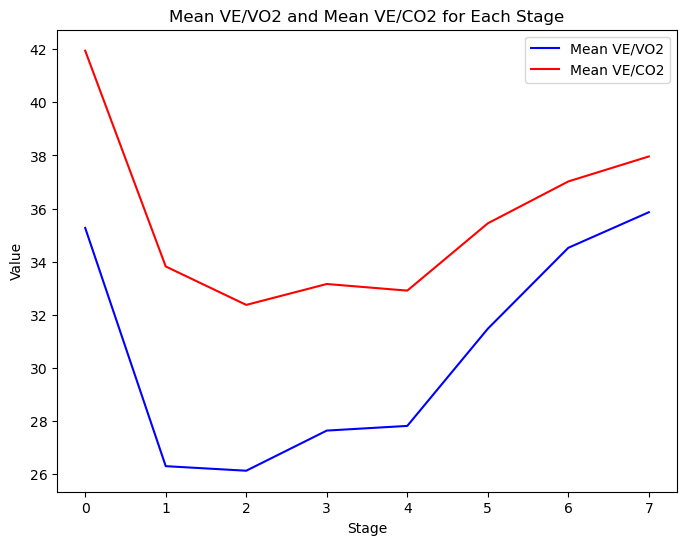

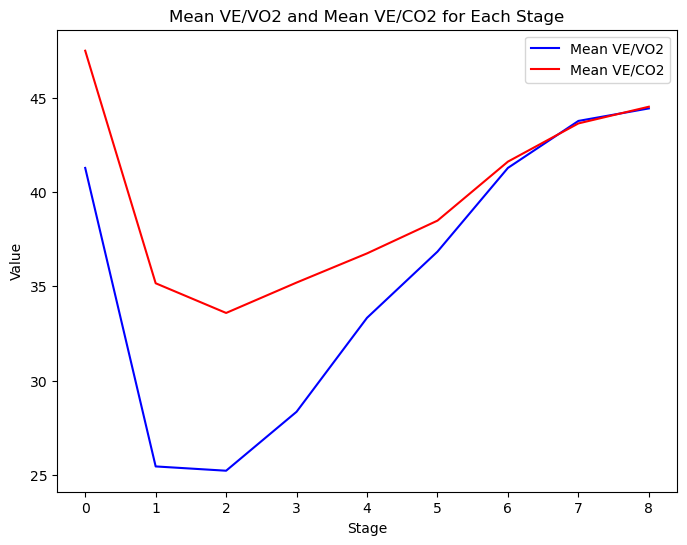

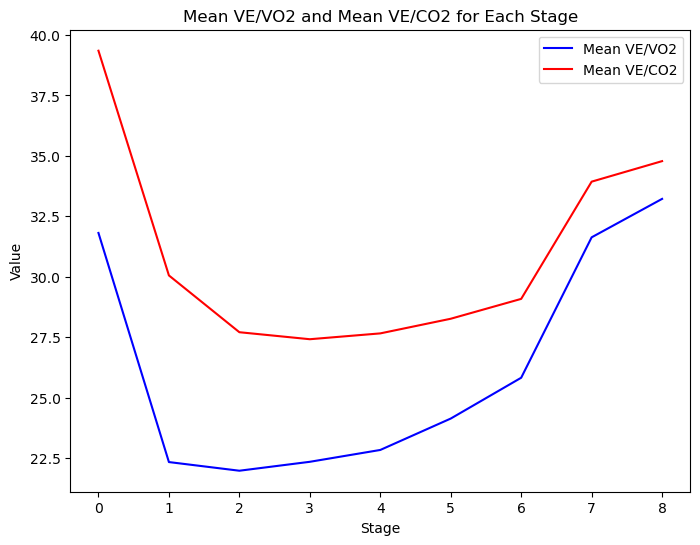

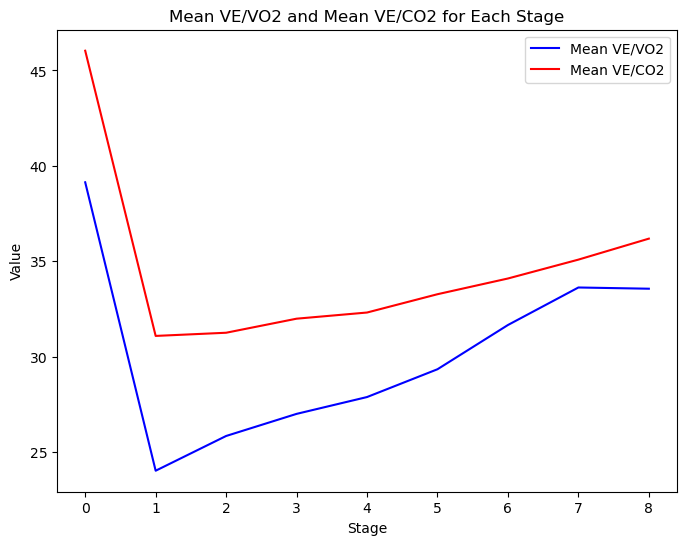

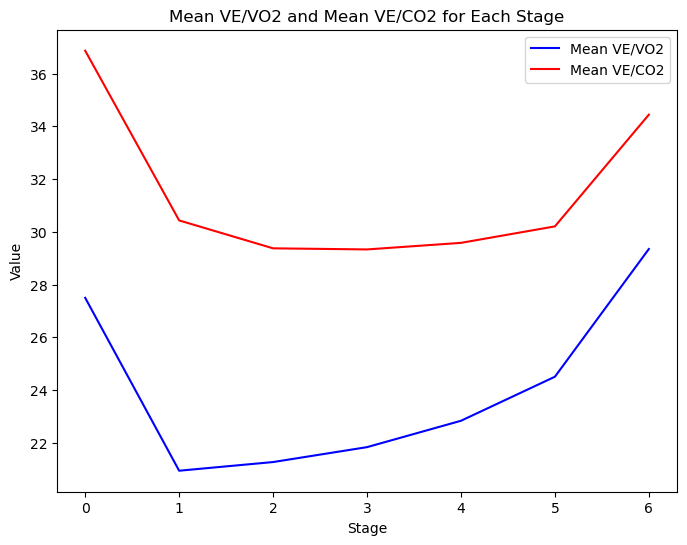

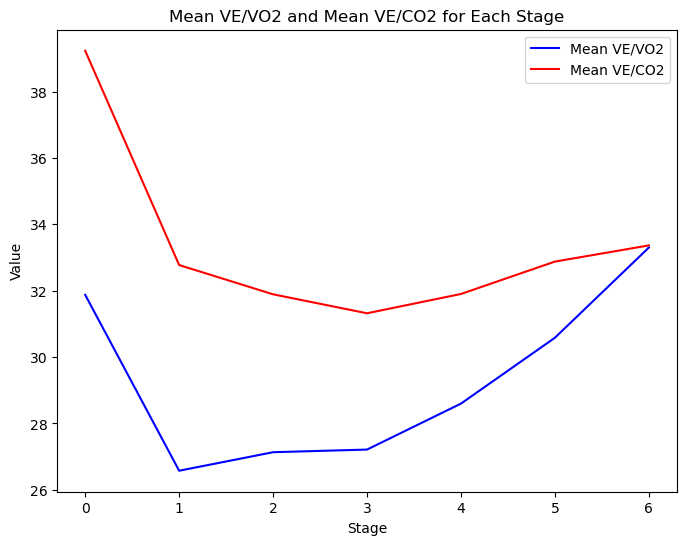

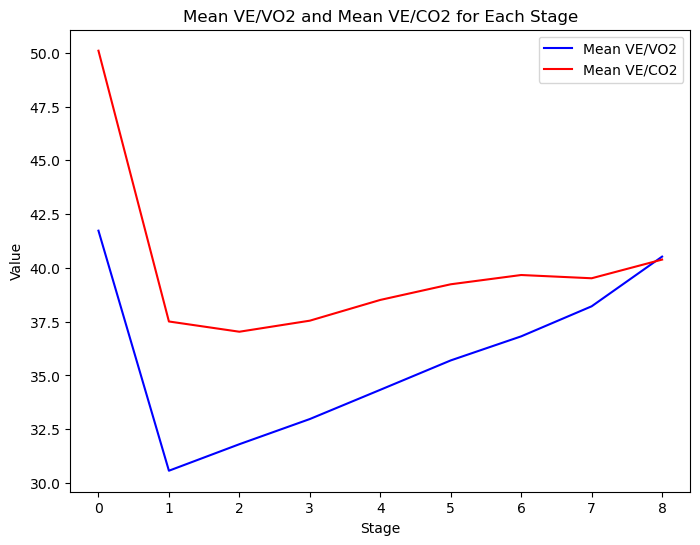

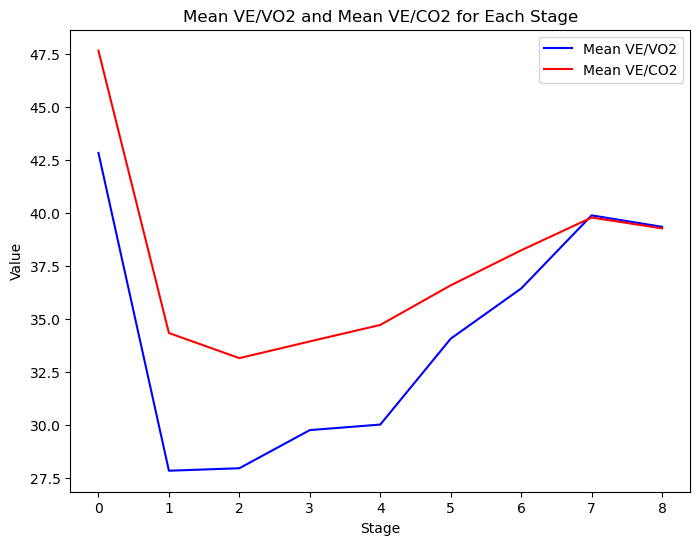

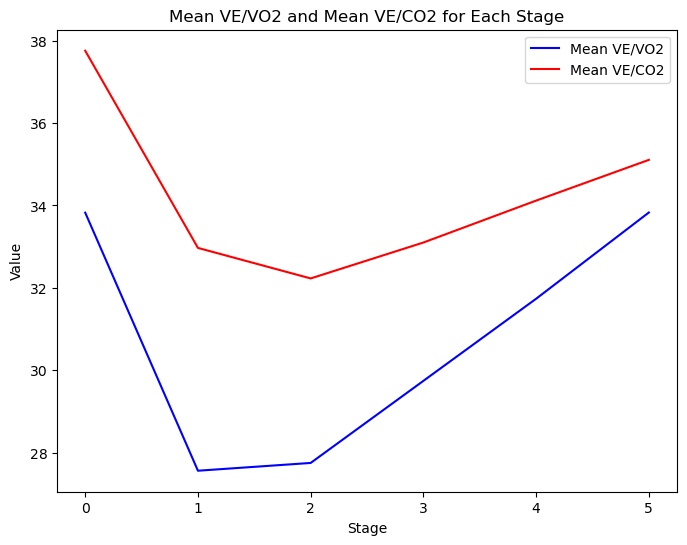

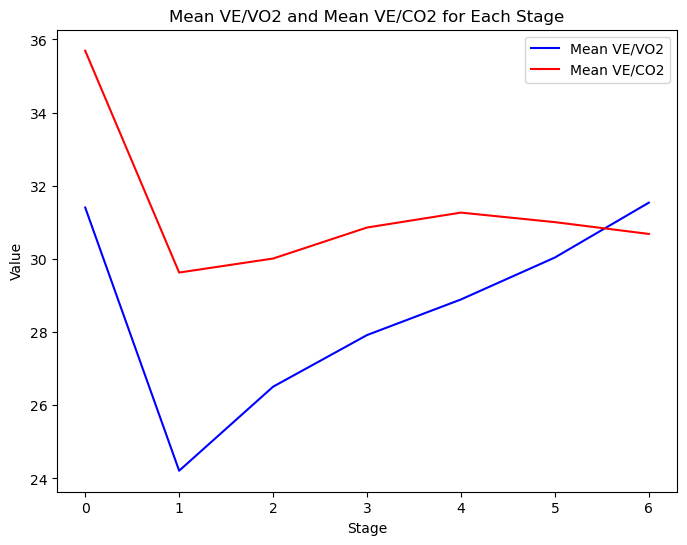

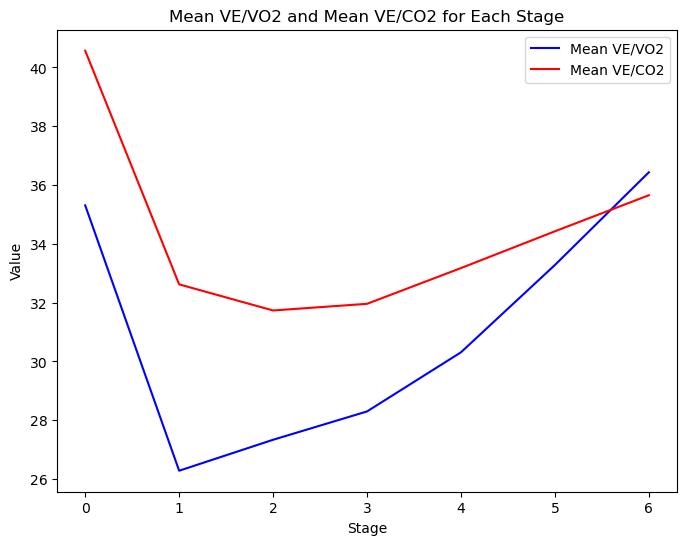

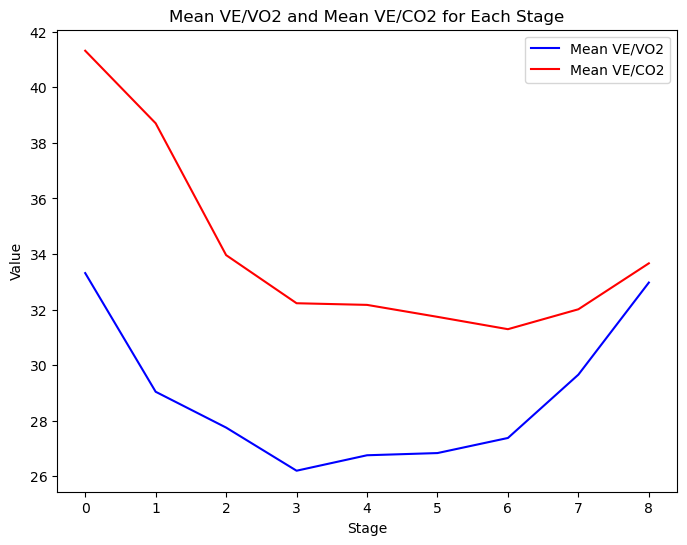

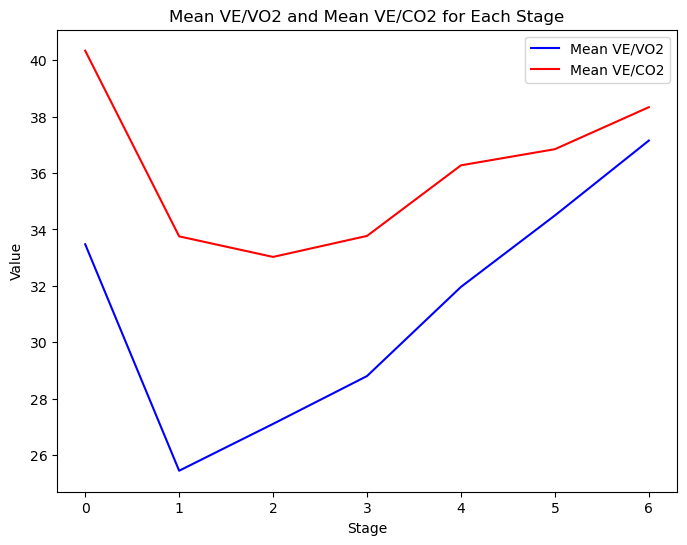

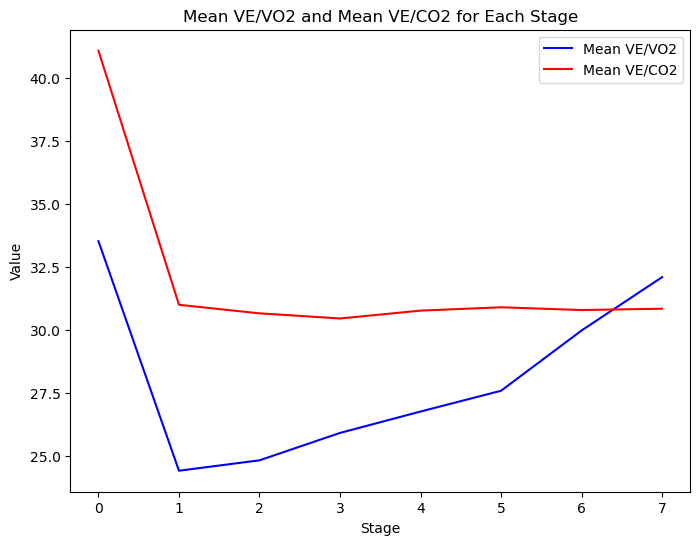

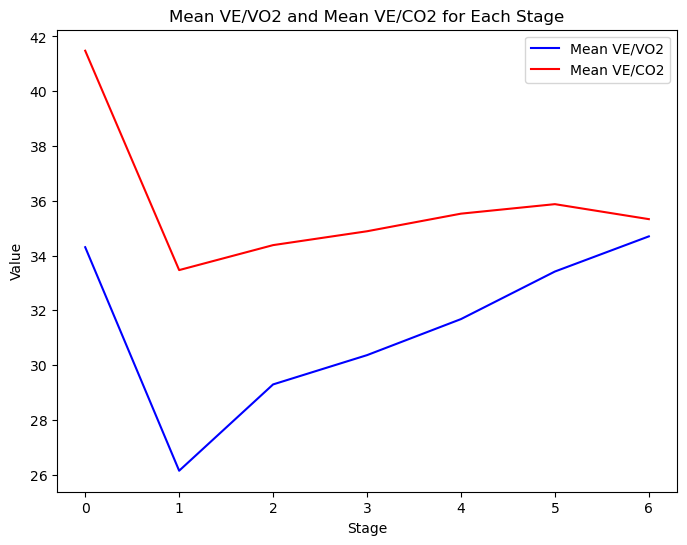

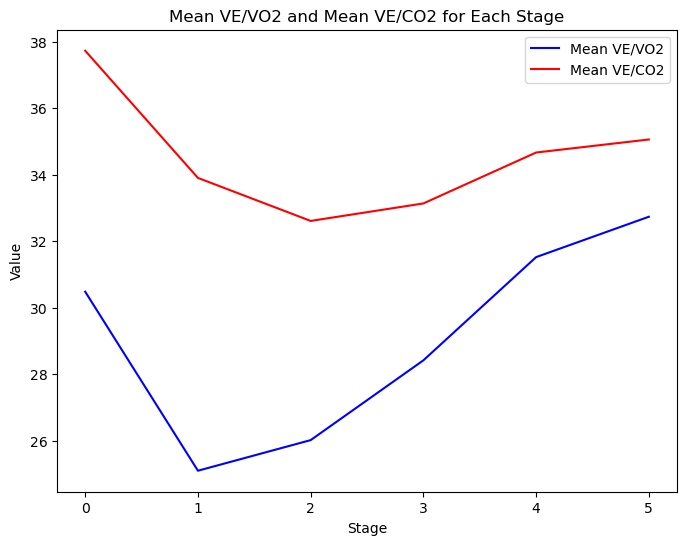

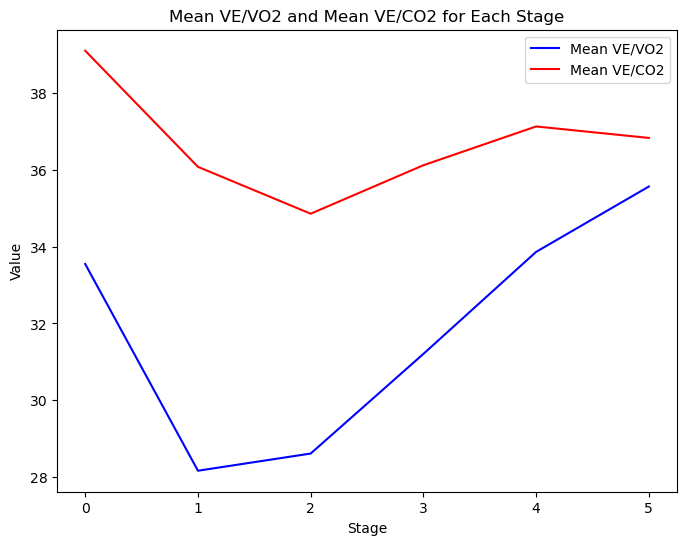

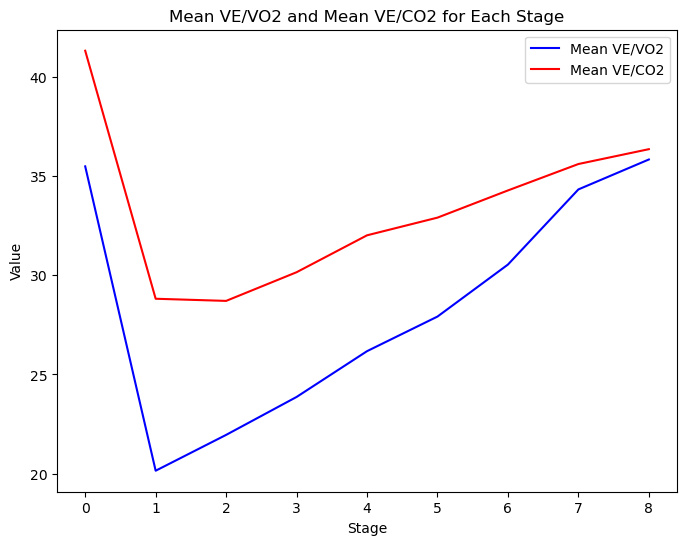

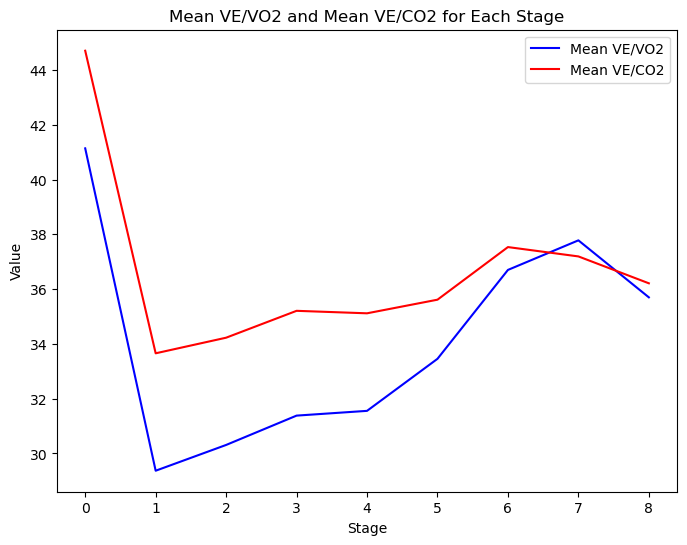

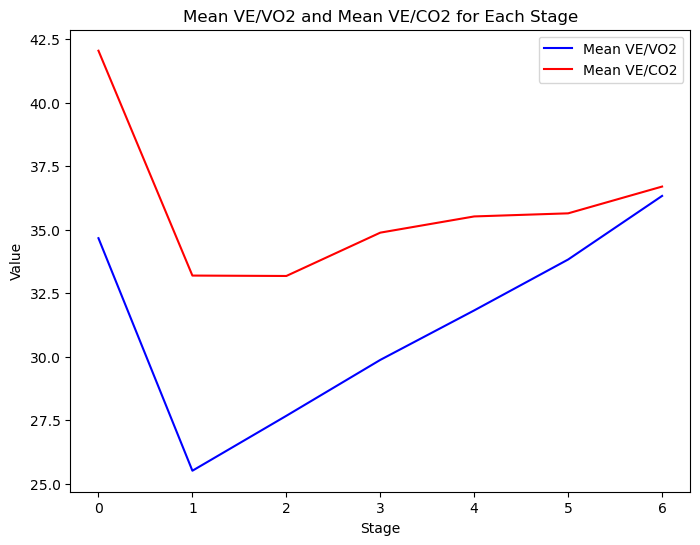

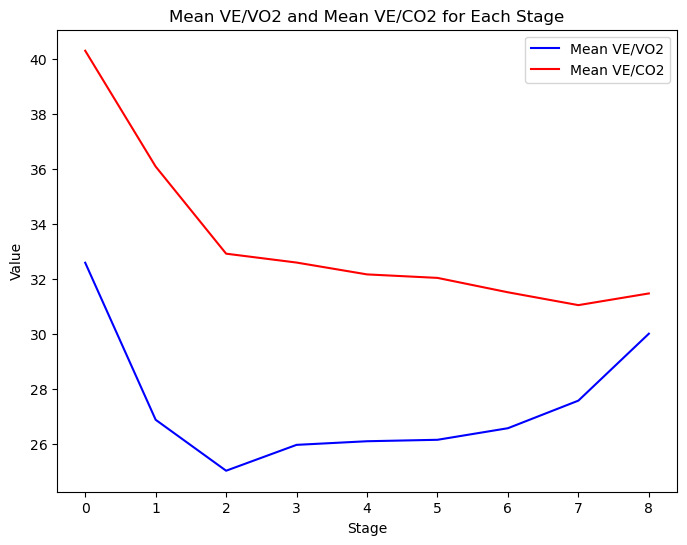

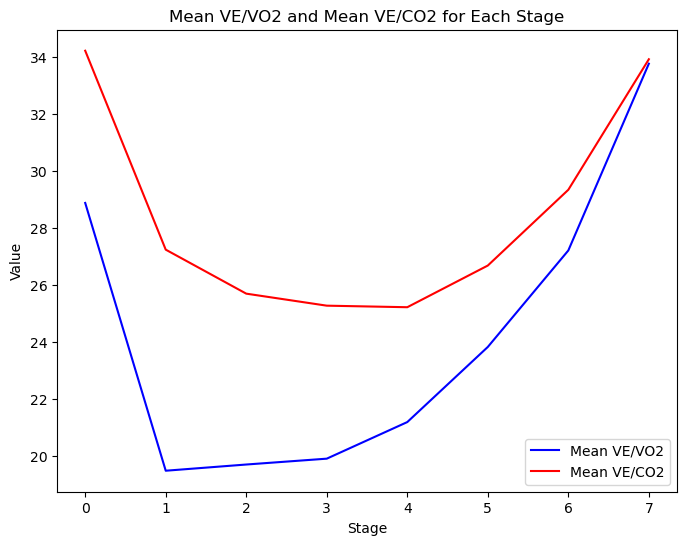

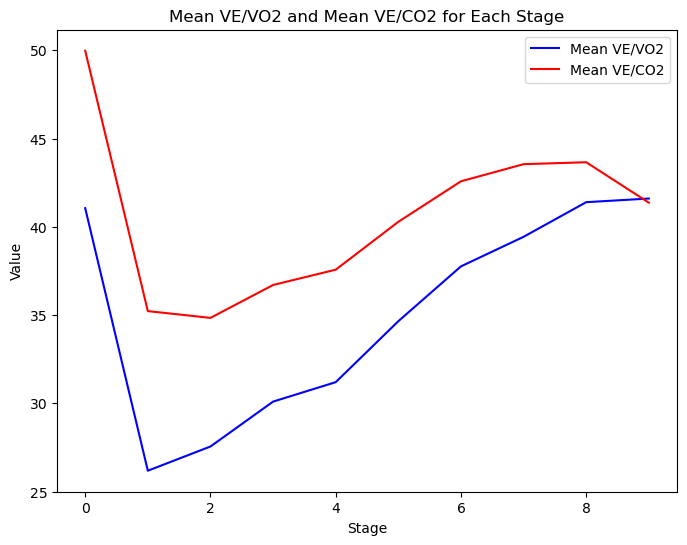

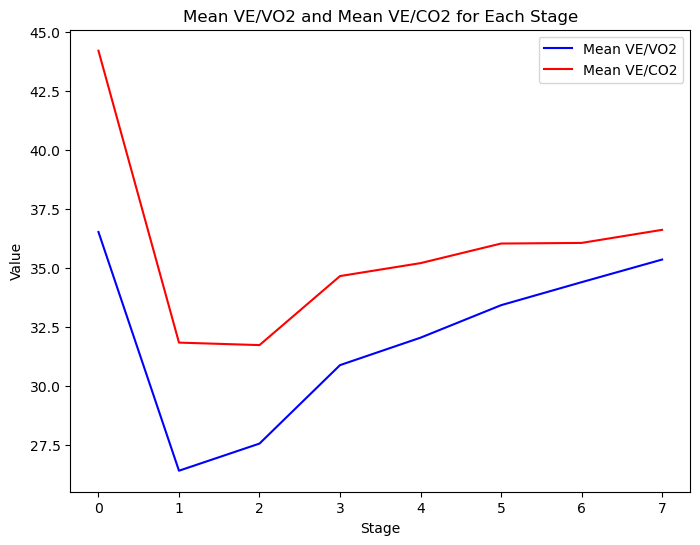

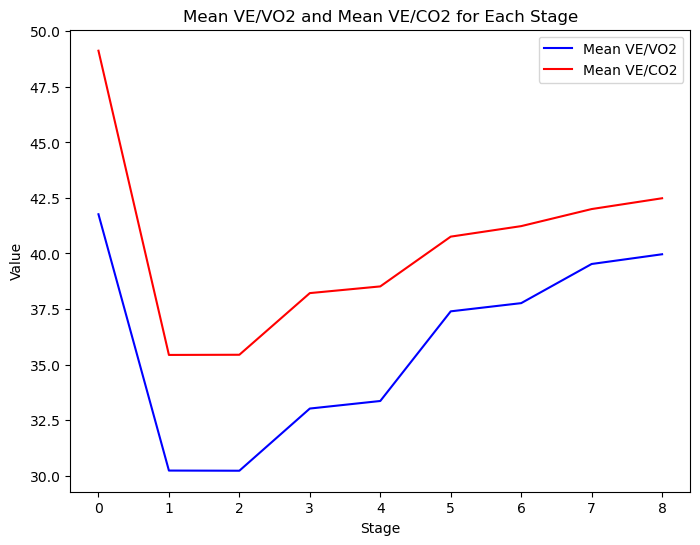

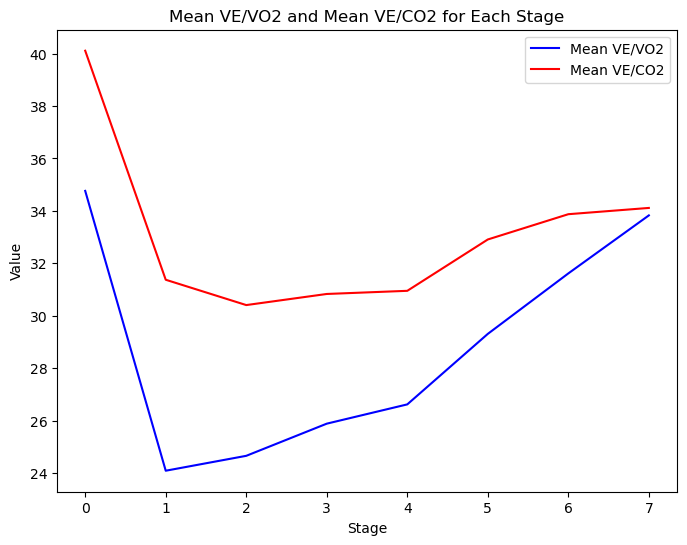

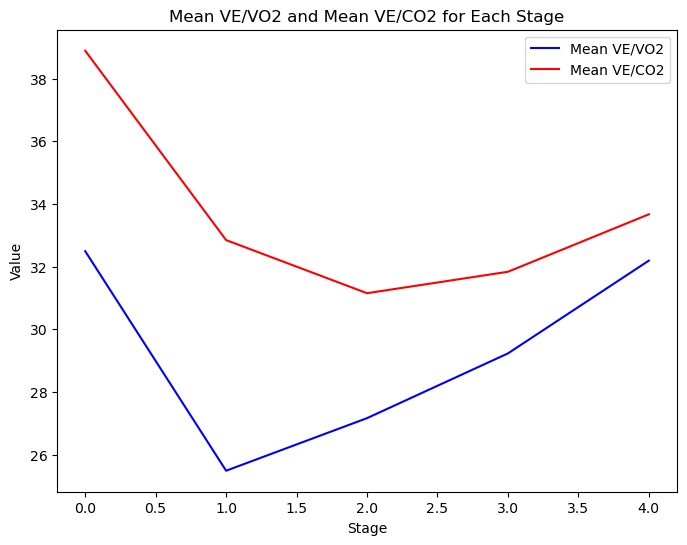

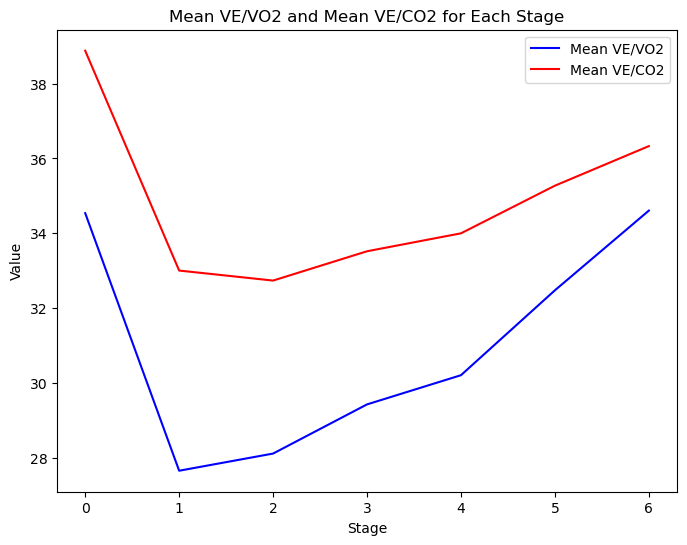

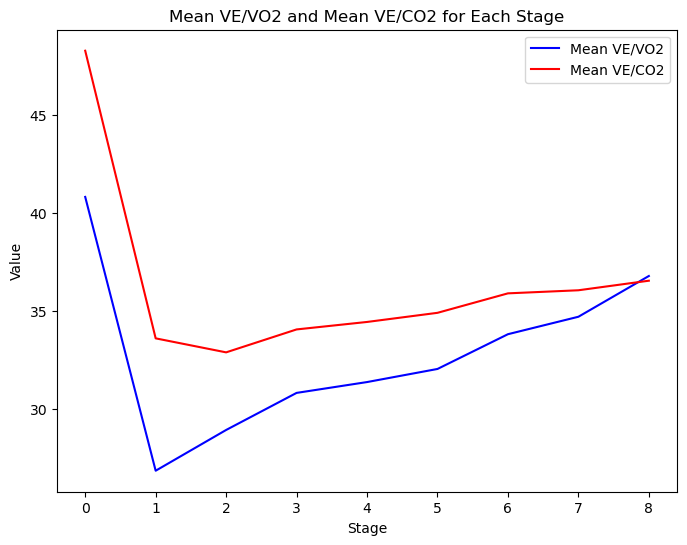

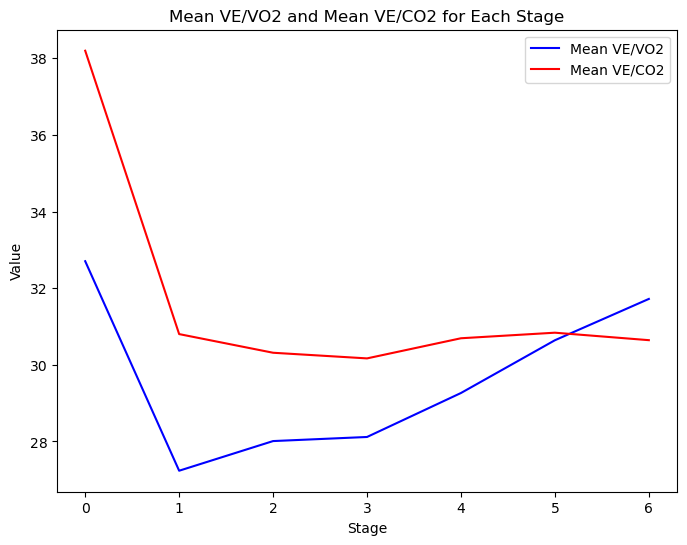

In [280]:
path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))
for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test.ve_vs_wl()

In [246]:
path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))
schema = {'aerobic_time':'float', 'aerobic_O2_val':'float', 'aerobic_CO2_val':'float', 'anaerobic_time':'float', 'anaerobic_O2_val':'float', 'anaerobic_CO2_val':'float'}
for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    window_size_df = pd.DataFrame(columns=schema.keys()).astype(schema)
    results = []  # Use a list to store results before concatenating
    for i in range(1, 120):
        try:
            result = test.aerobic_anaerobic_3(i)  # Assuming this returns a dictionary or a Series
            result["window_size"] = i  # Add window size as a column
            results.append(result)  # Store result in list
        except Exception as e:
            print(f"Skipping window size {i} due to error: {e}")

    # Convert results to DataFrame in one step
    '''
    if results:
        window_size_df = pd.concat([window_size_df, pd.DataFrame(results)], ignore_index=True)

    window_size_df
    window_size_df.plot(x='window_size', y=['aerobic_time', 'anaerobic_time'], kind='line')
    plt.xlabel('Window Size')
    plt.ylabel('Time to reach threshold (s)')
    plt.title(f'{test.name}: Aerobic Time and Anaerobic Time vs Window Size')
    plt.legend(['Aerobic Time', 'Anaerobic Time'])
    plt.show()

    
    window_size_df.plot(x='window_size', y=['aerobic_O2_val', 'anaerobic_O2_val'], kind='line')
    plt.xlabel('Window Size')
    plt.title(f'{test.name}: Aerobic and Anaerobic O2 values vs Window Size')
    plt.ylabel('Threshold O2 Value')
    plt.legend(['Aerobic O2', 'Anaerobic O2'])
    plt.show()
    window_size_df.plot(x='window_size', y=['aerobic_CO2_val', 'anaerobic_CO2_val'], kind='line')
    plt.xlabel('Window Size')
    plt.ylabel('Threshold CO2 Value')
    plt.title(f'{test.name}: Aerobic and Anaerobic CO2 values vs Window Size')
    plt.legend(['Aerobic CO2', 'Anaerobic CO2'])
    plt.show()
    '''


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b 

In [149]:
path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))

folder_name = "vo2_vco2_graphs"

for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_name = test.name  # Assuming each test has a unique name
    try:
        fig, vo2_threshold, vco2_threshold = test.aerobic_1()  # Correct unpacking
        fig.savefig(f'{folder_name}/{test_name}_aerobic_1.png')
        plt.close(fig)  # Free memory
        
        print(f"{test_name}: Aerobic 1 threshold: {vo2_threshold:.2f} L/min, {vco2_threshold:.2f} L/min")
    except Exception as e:
        print(f"Error processing {test_name}: {e}")

/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_18537/1844921518.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df['Stage'].fillna(0, inplace=True)  # Ensure non-exercise rows have Stage 0


TR000105_20220207: Aerobic 1 threshold: -1382.24 L/min, -1517.95 L/min


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_18537/1844921518.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df['Stage'].fillna(0, inplace=True)  # Ensure non-exercise rows have Stage 0


TR000106_20220420: Aerobic 1 threshold: -339.70 L/min, -568.94 L/min


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_18537/1844921518.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df['Stage'].fillna(0, inplace=True)  # Ensure non-exercise rows have Stage 0


...

TR000101_20220331: Aerobic 1 threshold: -679.88 L/min, -850.67 L/min


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_18537/1844921518.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df['Stage'].fillna(0, inplace=True)  # Ensure non-exercise rows have Stage 0


TR000107_20220805: Aerobic 1 threshold: -2307.16 L/min, -2439.53 L/min


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_18537/1844921518.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df['Stage'].fillna(0, inplace=True)  # Ensure non-exercise rows have Stage 0


TR000109_20220518: Aerobic 1 threshold: -628.40 L/min, -741.27 L/min


In [240]:
import pandas as pd
import glob
import os

path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))

results = []
folder_name = "lactate_graphs"

for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_name = test.name  # Assuming each test has a unique name
    test_results = test.lt_ref_vals()
    test_results.update(test.lt_abs_vals())
    if test.lt_log_semilog():
        test_results.update(test.lt_log_semilog())
    test_results['Test Name'] = test_name
    
    # Append results to the list
    results.append(test_results)

# Convert results into a DataFrame
results_df = pd.DataFrame(results).set_index('Test Name')

# Display the DataFrame (optional)
results_df

,LT1_ref,LT2_ref,LT1ref_speed,LT2ref_speed,LT1_abs,LT2_abs,LT1abs_speed,LT2abs_speed,LT1_log,LT1_log_speed,LT1_log_r2,LT2_semilog,LT2_semilog_speed,LT2_semi_log_r2
Test Name,,,,,,,,,,,,,,
TR000105_20220207,3.6,3.6,4.8,4.8,2.1,4.7,2.0,6.0,5.574446,7.015555,0.855457,6.863055,6.136242,0.914631
TR000106_20220420,2.4,4.3,7.1,8.3,2.4,4.3,7.1,8.3,1.906243,6.594936,0.949458,6.593568,1.910062,0.952030
TR000102_20220204,4.2,4.2,6.8,6.8,3.2,4.2,2.0,6.8,3.701032,8.985182,0.315441,8.967361,3.806786,0.329163
TR000100_20220623,2.5,5.0,8.6,9.8,2.9,5.0,2.0,9.8,2.003482,8.492251,0.567424,8.407638,1.946956,0.584825
TR000104_20220627,3.2,10.4,8.8,8.8,2.6,10.4,2.0,8.8,2.232814,8.687540,0.501426,8.622199,2.191050,0.533642
TR000100_20220331,2.1,3.5,9.2,9.8,2.1,4.1,2.0,2.0,1.592061,8.415150,0.750100,8.391522,1.559386,0.779775
TR000109_20220209,4.1,4.1,6.9,6.9,3.1,4.1,2.0,6.9,4.487763,7.909333,0.544670,7.936506,4.677765,0.621858
TR000107_20220519,3.5,3.5,8.0,8.0,2.1,7.5,2.0,10.5,2.168712,10.029869,0.360399,9.978255,2.122445,0.358410
TR000106_20220208,3.1,5.8,5.8,6.5,2.6,5.8,2.0,6.5,5.982798,8.063484,0.550467,8.164476,6.641185,0.561781


In [116]:
results_df['LT1/LT2_Ref_same'] = results_df['LT1_ref'] == results_df['LT2_ref']
results_df['LT1/LT2_Abs_same'] = results_df['LT1_abs'] == results_df['LT2_abs']
results_df['LT1_Ref_Abs_same'] = results_df['LT1_ref'] == results_df['LT1_abs']
results_df['LT2_Ref_Abs_same'] = results_df['LT2_ref'] == results_df['LT2_abs']
results_df['LT1log_speed>LT2log_speed'] = results_df['LT1_log_speed'] > results_df['LT2_semilog_speed']
results_df['LT1_log>LT2_semilog'] = results_df['LT1_log'] > results_df['LT2_semilog']
results_df = results_df.sort_index()
results_df.sort_values(by='LT1_log_r2', ascending=False)


,LT1_ref,LT2_ref,LT1ref_speed,LT2ref_speed,LT1_abs,LT2_abs,LT1abs_speed,LT2abs_speed,LT1_log,LT1_log_speed,LT1_log_r2,LT2_semilog,LT2_semilog_speed,LT2_semi_log_r2,LT1/LT2_Ref_same,LT1/LT2_Abs_same,LT1_Ref_Abs_same,LT2_Ref_Abs_same,LT1log_speed>LT2log_speed,LT1_log>LT2_semilog
Test Name,,,,,,,,,,,,,,,,,,,,
TR000108_20220209,3.7,3.7,5.4,5.4,2.1,5.5,2.0,6.6,3.915427,6.006571,0.999937,6.047295,4.007126,0.997640,True,False,False,False,True,False
TR000101_20220331,3.4,4.8,6.5,8.3,2.6,4.8,2.0,8.3,3.569491,7.682926,0.998524,7.712744,3.622065,0.999232,False,False,False,True,True,False
TR000110_20220428,2.1,3.3,6.3,7.5,2.1,5.9,6.3,8.1,2.127867,6.922036,0.994310,6.906890,2.144034,0.989008,False,False,True,False,True,False
TR000103_20220204,3.6,3.6,8.0,8.0,2.1,4.2,2.0,8.6,3.911724,8.378838,0.982948,8.381042,3.928585,0.989746,True,False,False,False,True,False
TR000103_20220401,5.9,5.9,9.3,9.3,3.5,5.9,2.0,9.3,2.213647,8.634403,0.973741,8.627891,2.188238,0.982329,True,False,False,True,True,False
TR000106_20220420,2.4,4.3,7.1,8.3,2.4,4.3,7.1,8.3,1.906243,6.594936,0.949458,6.593568,1.910062,0.952030,False,False,True,True,True,False
TR000109_20220824,4.3,4.3,8.8,8.8,2.2,4.3,6.3,8.8,2.382520,8.137912,0.948005,8.159454,2.425536,0.931522,True,False,False,True,True,False
TR000109_20220518,2.8,4.4,6.3,7.5,2.2,4.4,2.0,7.5,3.060430,6.692052,0.946224,6.631433,3.058710,0.956863,False,False,False,True,True,False
TR000110_20220901,1.8,6.8,6.3,8.1,2.3,6.8,6.9,8.1,2.073628,6.853761,0.926557,6.834631,2.096206,0.940022,False,False,False,True,True,False


In [130]:
results_df['LT1_log - LT1 ref'] = results_df['LT1_log'] - results_df['LT1_ref']
results_df['LT2_semilog - LT2 ref'] = results_df['LT2_semilog'] - results_df['LT2_ref']
results_df['LT1_log - LT1_abs'] = results_df['LT1_log'] - results_df['LT1_abs']
results_df['LT2_semilog - LT2_abs'] = results_df['LT2_semilog'] - results_df['LT2_abs']
results_df = results_df[results_df['LT2_semilog'] < 20]
print(abs(results_df['LT1_log - LT1_abs']).describe())
print(abs(results_df['LT2_semilog - LT2_abs']).describe())
#print(abs(results_df['LT1_log - LT1 ref']).describe())
#print(abs(results_df['LT2_semilog - LT2 ref']).describe())

count    30.000000
mean      1.024404
std       0.959331
min       0.027867
25%       0.266281
50%       0.873730
75%       1.401279
max       3.474446
Name: LT1_log - LT1_abs, dtype: float64
count    30.000000
mean      2.708238
std       1.620058
min       0.034631
25%       1.728784
50%       2.329022
75%       4.100645
max       5.648262
Name: LT2_semilog - LT2_abs, dtype: float64


/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_57705/4271827488.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['LT1_log - LT1 ref'] = results_df['LT1_log'] - results_df['LT1_ref']
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_57705/4271827488.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_df['LT2_semilog - LT2 ref'] = results_df['LT2_semilog'] - results_df['LT2_ref']
/var/folders/00/25nsh44n6l12wt18fkf86ns80000gn/T/ipykernel_57705/4271827488.py:3: Settin

In [129]:
results_df['LT2_semilog'].sort_values(ascending=False)

Test Name
TR000107_20220519    9.978255
TR000107_20220805    9.819362
TR000103_20220706    9.648262
TR000102_20220401    9.556322
TR000107_20220208    9.536177
TR000102_20220204    8.967361
TR000103_20220401    8.627891
TR000104_20220627    8.622199
TR000102_20220630    8.614629
TR000100_20220623    8.407638
TR000100_20220331    8.391522
TR000103_20220204    8.381042
TR000104_20220314    8.270761
TR000106_20220208    8.164476
TR000109_20220824    8.159454
TR000109_20220209    7.936506
TR000101_20220331    7.712744
TR000106_20220823    7.567625
TR000110_20220210    7.440470
TR000101_20220630    7.071249
TR000110_20220428    6.906890
TR000105_20220920    6.895285
TR000105_20220207    6.863055
TR000110_20220901    6.834631
TR000109_20220518    6.631433
TR000106_20220420    6.593568
TR000105_20220517    6.322675
TR000108_20220209    6.047295
TR000104_20220207    4.826963
TR000101_20220203    0.668274
Name: LT2_semilog, dtype: float64